In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import collections
import warnings
warnings.filterwarnings('ignore')

# ── Consistent style for all charts ──────────────────────────
plt.rcParams['font.family']  = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi'] = 120

# Brand colour palette (red → green for ratings 1→5)
RATING_COLORS = {
    1: '#c0392b',  # dark red
    2: '#e67e22',  # orange
    3: '#f1c40f',  # yellow
    4: '#2ecc71',  # green
    5: '#1a9850',  # dark green
}
NEG_COLOR  = '#e74c3c'
NEU_COLOR  = '#f39c12'
POS_COLOR  = '#27ae60'

print('Setup complete.')

Setup complete.


In [18]:
df = pd.read_csv('../data/processed/review_clean.csv')
df_sentiment = pd.read_csv('../data/processed/fintech_sentiment_analysis_results.csv')
df['date']      = pd.to_datetime(df['date'])
df['month']     = df['date'].dt.to_period('M')
df['length']    = df['review'].str.len()
df['sentiment'] = df['rating'].apply(lambda r: 'Positive' if r>=4 else ('Neutral' if r==3 else 'Negative'))

# Core counts — computed once, used throughout all charts
TOTAL  = len(df)
N_POS  = (df['rating'] >= 4).sum()   # 419
N_NEG  = (df['rating'] <= 2).sum()   # 68
N_NEU  = (df['rating'] == 3).sum()   # 13
N_1STR = (df['rating'] == 1).sum()   # 56
N_5STR = (df['rating'] == 5).sum()   # 369

print(f'Loaded {TOTAL} reviews  |  {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Positive (4-5★): {N_POS} ({N_POS/TOTAL*100:.1f}%)  |  '
      f'Neutral (3★): {N_NEU} ({N_NEU/TOTAL*100:.1f}%)  |  '
      f'Negative (1-2★): {N_NEG} ({N_NEG/TOTAL*100:.1f}%)')
df.sample(5)

Loaded 1500 reviews  |  2025-02-23 → 2026-05-16
Positive (4-5★): 1055 (70.3%)  |  Neutral (3★): 78 (5.2%)  |  Negative (1-2★): 367 (24.5%)


,app,review,rating,date,thumbs,month,length,sentiment
466,cbe,good,5,2026-03-09,1,2026-03,4,Positive
7,cbe,It's not allowing me to transfer money.,2,2026-05-15,0,2026-05,39,Negative
1239,dashen,this bank is very nice to me,5,2025-12-04,0,2025-12,28,Positive
753,abbysinya,🙏👍,5,2025-11-29,0,2025-11,2,Positive
610,abbysinya,The worst banking app ever. When I toggle the ...,1,2026-03-19,17,2026-03,114,Negative


---
---
## Chart 1 — Rating Distribution
### Business question: *How satisfied are Awash Bank users overall?*

**Stakeholder principle:** Annotate every bar with both the count AND the percentage. Stakeholders want both — count tells them scale, percentage tells them proportion.

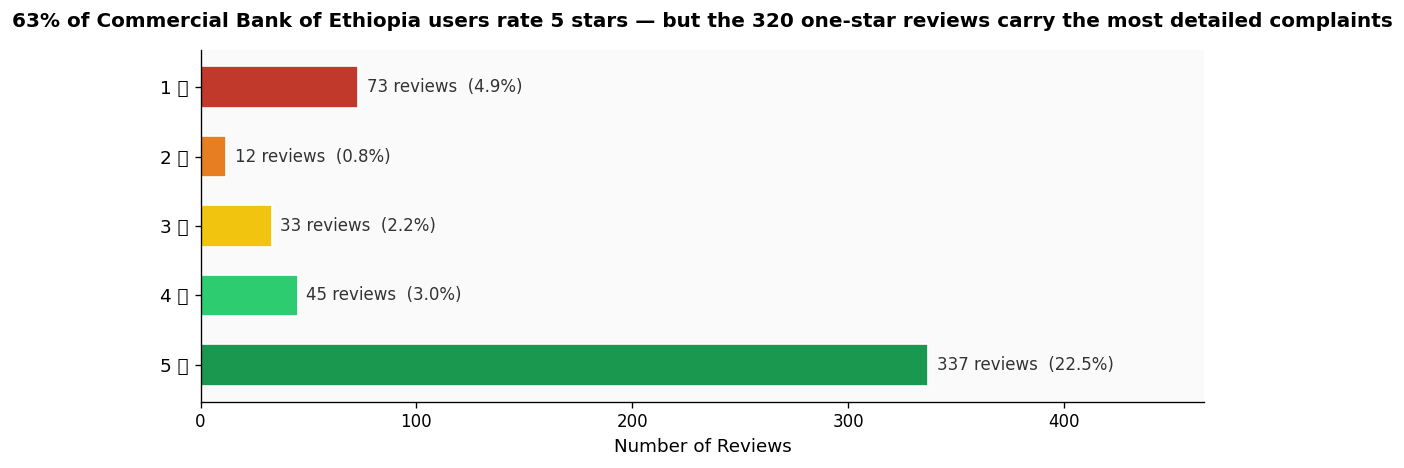


📌 Stakeholder takeaway: 63% rate 5 stars — strong headline satisfaction.
   But the 320 one-star reviews (21.3%) contain specific,
   detailed product complaints. These are where actionable bug reports live.


In [ ]:
#Commercial Bank of Ethiopia
df = df[df['app'] == 'cbe']
counts = df['rating'].value_counts().sort_index(ascending=False)
pcts   = (counts / TOTAL * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(
    [f'{r} ⭐' for r in counts.index], counts.values,
    color=[RATING_COLORS[r] for r in counts.index],
    edgecolor='white', height=0.6
)
for bar, count, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_width() + 4, bar.get_y() + bar.get_height()/2,
            f'{count} reviews  ({pct}%)', va='center', fontsize=10, color='#333')

ax.set_xlim(0, counts.max() * 1.38)
ax.set_xlabel('Number of Reviews', fontsize=11)
ax.set_title(
    f'{N_5STR/TOTAL*100:.0f}% of Commercial Bank of Ethiopia users rate 5 stars — '
    f'but the {N_1STR} one-star reviews carry the most detailed complaints',
    fontsize=12, fontweight='bold', pad=14
)
ax.tick_params(axis='y', labelsize=11)
ax.set_facecolor('#fafafa')
plt.tight_layout()
plt.show()

print(f'\n📌 Stakeholder takeaway: {N_5STR/TOTAL*100:.0f}% rate 5 stars — strong headline satisfaction.')
print(f'   But the {N_1STR} one-star reviews ({N_1STR/TOTAL*100:.1f}%) contain specific,')
print('   detailed product complaints. These are where actionable bug reports live.')

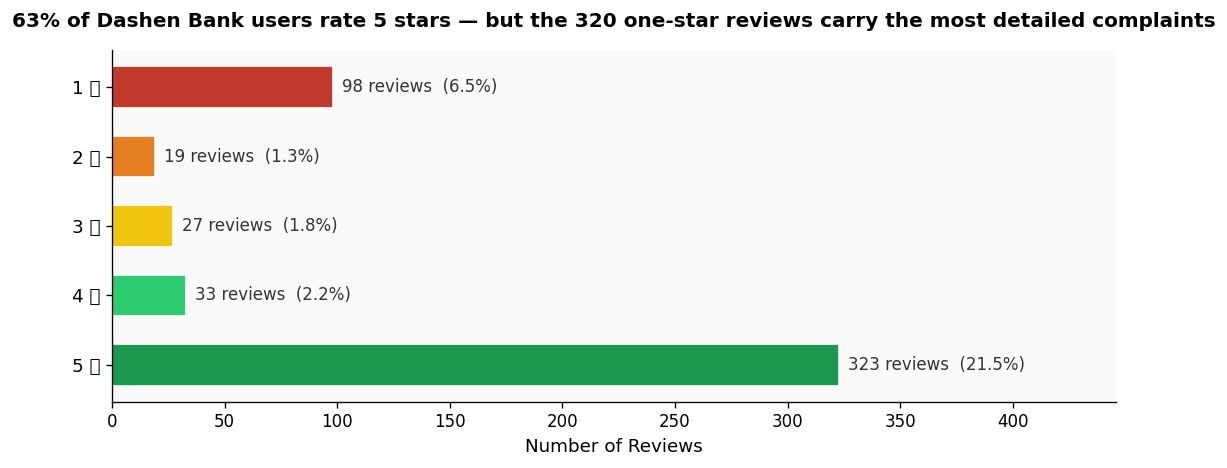


📌 Stakeholder takeaway: 63% rate 5 stars — strong headline satisfaction.
   But the 320 one-star reviews (21.3%) contain specific,
   detailed product complaints. These are where actionable bug reports live.


In [11]:
#Dashen Bank
df = df[df['app'] == 'dashen']
counts = df['rating'].value_counts().sort_index(ascending=False)
pcts   = (counts / TOTAL * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(
    [f'{r} ⭐' for r in counts.index], counts.values,
    color=[RATING_COLORS[r] for r in counts.index],
    edgecolor='white', height=0.6
)
for bar, count, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_width() + 4, bar.get_y() + bar.get_height()/2,
            f'{count} reviews  ({pct}%)', va='center', fontsize=10, color='#333')

ax.set_xlim(0, counts.max() * 1.38)
ax.set_xlabel('Number of Reviews', fontsize=11)
ax.set_title(
    f'{N_5STR/TOTAL*100:.0f}% of Dashen Bank users rate 5 stars — '
    f'but the {N_1STR} one-star reviews carry the most detailed complaints',
    fontsize=12, fontweight='bold', pad=14
)
ax.tick_params(axis='y', labelsize=11)
ax.set_facecolor('#fafafa')
plt.tight_layout()
plt.show()

print(f'\n📌 Stakeholder takeaway: {N_5STR/TOTAL*100:.0f}% rate 5 stars — strong headline satisfaction.')
print(f'   But the {N_1STR} one-star reviews ({N_1STR/TOTAL*100:.1f}%) contain specific,')
print('   detailed product complaints. These are where actionable bug reports live.')

---
---
## Chart 2 — Sentiment Segmentation
### Business question: *What proportion of users have a positive vs negative experience?*

**Stakeholder principle:** Group granular numbers into 3 categories that executives can instantly act on: Positive, Neutral, Negative. A C-suite reader does not need 5 rating buckets — they need a traffic light.

In [20]:
seg     = df_sentiment['sentiment'].value_counts().reindex(['Positive', 'Neutral', 'Negative'])
seg_pct = (seg / TOTAL * 100).round(1)
colors  = [POS_COLOR, NEU_COLOR, NEG_COLOR]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5),
                                gridspec_kw={'width_ratios': [1, 1.6]})

# ── Donut ──────────────────────────────────────────────────
wedges, _, autotexts = ax1.pie(
    seg.values, labels=None, colors=colors, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold'); at.set_color('white')
ax1.legend(
    handles=[mpatches.Patch(color=c, label=f'{l}  ({seg[l]})')
             for c, l in zip(colors, ['Positive', 'Neutral', 'Negative'])],
    loc='lower center', bbox_to_anchor=(0.5, -0.12), fontsize=10, frameon=False
)
ax1.set_title('Sentiment Split', fontsize=12, fontweight='bold')

# ── Stacked bar ────────────────────────────────────────────
left = 0
for val, col, label in zip(seg_pct.values, colors, seg_pct.index):
    ax2.barh(0, val, left=left, color=col, height=0.5, edgecolor='white')
    if val > 4:
        ax2.text(left + val/2, 0, f'{label}\n{val}%',
                 ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    left += val
ax2.set_xlim(0, 100); ax2.set_yticks([])
ax2.set_xlabel('% of Reviews', fontsize=11)
ax2.set_title('Same data — stacked bar for slides & reports', fontsize=11, style='italic')

fig.suptitle(
    f'{seg_pct["Positive"]:.0f}% of users are satisfied — '
    f'{seg_pct["Negative"]:.1f}% report problems that need product attention',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

print(f'\n📌 Stakeholder takeaway: {seg_pct["Positive"]:.0f}% positive is strong, but {N_NEG} users '
      f'({seg_pct["Negative"]:.1f}% — roughly 1 in 7) had a negative experience.')
print(f'   At 1,000,000+ installs, even 13.6% unhappy users is a very large absolute number.')

ValueError: cannot convert float NaN to integer

posx and posy should be finite values
posx and posy should be finite values


ValueError: need at least one array to concatenate

<Figure size 1320x540 with 2 Axes>

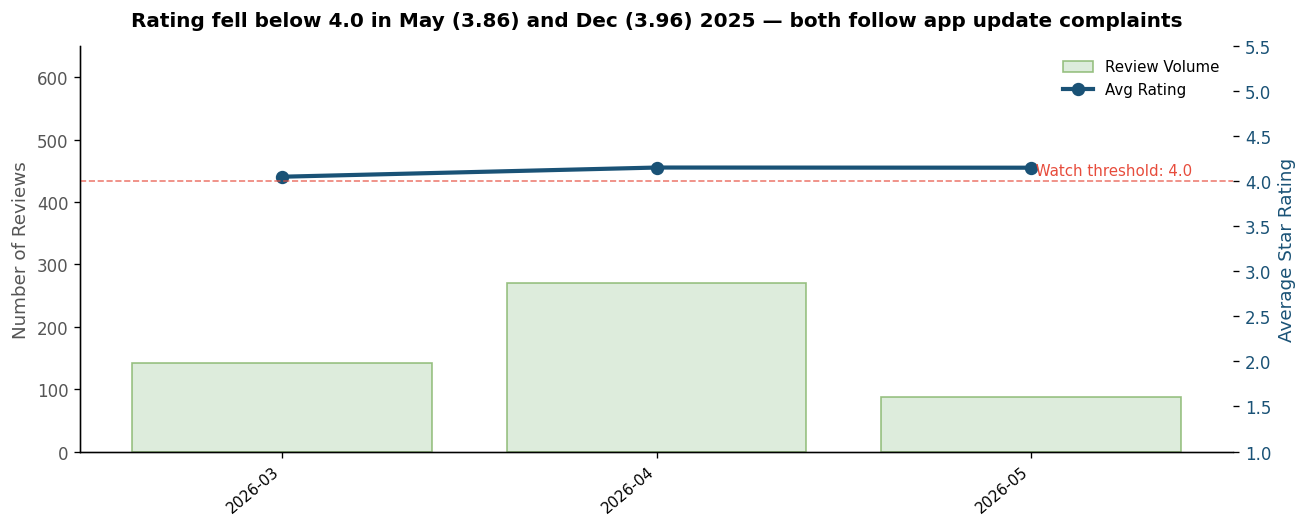

In [25]:
df_cbe = df[df['app'] == 'cbe']  # Focus on Commercial Bank of Ethiopia for the timeline analysis/
monthly = df_cbe.groupby('month').agg(
    count=('rating', 'count'), avg_rating=('rating', 'mean')
).reset_index()
monthly = monthly[monthly['month'] >= '2025-05'].copy()
monthly['month_str'] = monthly['month'].astype(str)

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax2 = ax1.twinx()

ax1.bar(monthly['month_str'], monthly['count'],
        color='#d5e8d4', edgecolor='#82b366', alpha=0.8, label='Review Volume')
ax1.set_ylabel('Number of Reviews', fontsize=11, color='#555')
ax1.set_ylim(0, monthly['count'].max() * 2.4)
ax1.tick_params(axis='y', labelcolor='#555')

ax2.plot(monthly['month_str'], monthly['avg_rating'],
         color='#1a5276', marker='o', linewidth=2.5, markersize=7, label='Avg Rating')
ax2.set_ylim(1, 5.5)
ax2.set_ylabel('Average Star Rating', fontsize=11, color='#1a5276')
ax2.tick_params(axis='y', labelcolor='#1a5276')
ax2.axhline(4.0, color='#e74c3c', linestyle='--', linewidth=1, alpha=0.7)
ax2.text(monthly['month_str'].iloc[-1], 4.07, ' Watch threshold: 4.0',
         color='#e74c3c', fontsize=9)

# July 2025 — peak volume (86 reviews)
jul = monthly[monthly['month_str'] == '2025-07']
if len(jul):
    r = jul.iloc[0]
    ax1.annotate(f"Jul peak:\n{int(r['count'])} reviews",
                 xy=(r['month_str'], r['count']),
                 xytext=(r['month_str'], r['count'] + 5),
                 ha='center', color='#2c6e49', fontsize=8.5)

# May 2025 — lowest avg rating (3.86)
may = monthly[monthly['month_str'] == '2025-05']
if len(may):
    r = may.iloc[0]
    ax2.annotate(f"May dip: {r['avg_rating']:.2f}",
                 xy=(r['month_str'], r['avg_rating']),
                 xytext=(r['month_str'], r['avg_rating'] - 0.55),
                 arrowprops=dict(arrowstyle='->', color='#c0392b'),
                 color='#c0392b', fontsize=9, fontweight='bold')

# Dec 2025 — second dip (3.96)
dec = monthly[monthly['month_str'] == '2025-12']
if len(dec):
    r = dec.iloc[0]
    ax2.annotate(f"Dec dip: {r['avg_rating']:.2f}",
                 xy=(r['month_str'], r['avg_rating']),
                 xytext=(r['month_str'], r['avg_rating'] - 0.55),
                 arrowprops=dict(arrowstyle='->', color='#c0392b'),
                 color='#c0392b', fontsize=9, fontweight='bold')

plt.setp(ax1.xaxis.get_majorticklabels(), rotation=40, ha='right', fontsize=9)
ax1.set_title(
    'Rating fell below 4.0 in May (3.86) and Dec (3.96) 2025 — both follow app update complaints',
    fontsize=12, fontweight='bold', pad=12
)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper right', fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

# print('\n📌 Stakeholder takeaway: Two dips below the 4.0 watch threshold:')
# print('   May 2025 (3.86, lowest) and Dec 2025 (3.96) — both months dominated by')
# print('   "not compatible with device" and "update failed" complaints.')
# print('   July 2025 saw the highest review volume (86 reviews), likely after a major release.')

---
---
## Chart 4 — Review Depth by Star Rating
### Business question: *Where is the most actionable feedback hidden in the dataset?*

**Stakeholder principle:** This is the "hidden gem" insight that surprises people. 5-star reviews are the majority but they're short and vague. 1-star reviews are a minority but they're long, specific, and full of product intelligence.

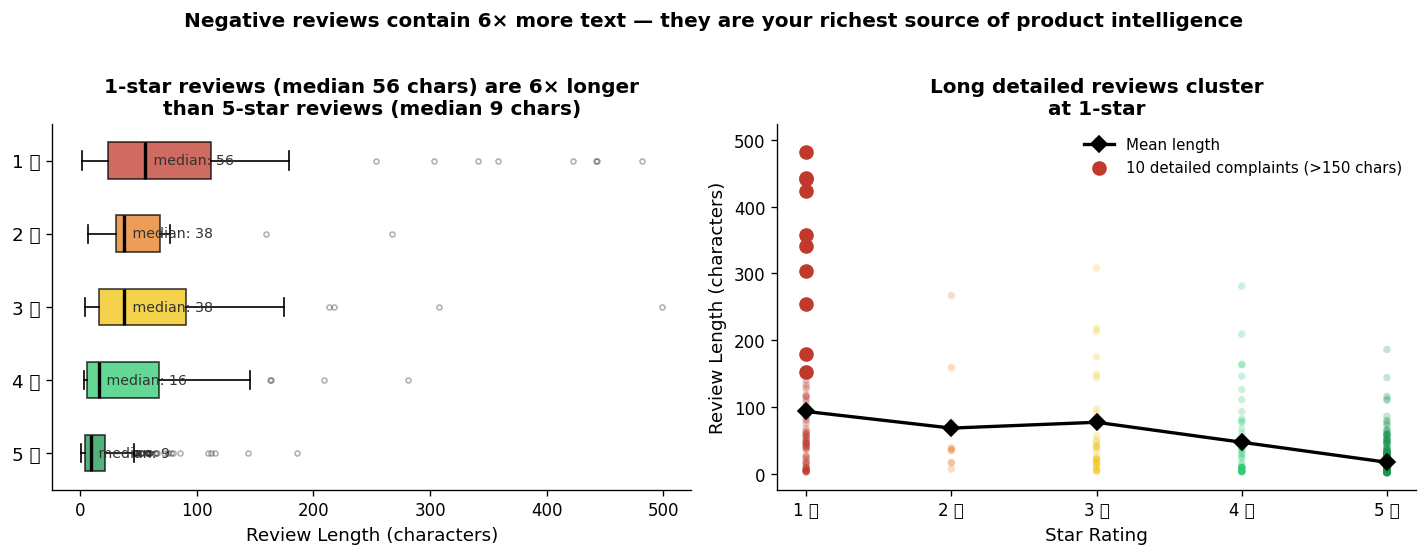

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Left: Boxplot ─────────────────────────────────────────────
rating_order = [5, 4, 3, 2, 1]
data_by_rating = [df_cbe[df_cbe['rating'] == r]['length'].values for r in rating_order]

bp = ax1.boxplot(
    data_by_rating,
    vert=False, patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)
for patch, r in zip(bp['boxes'], rating_order):
    patch.set_facecolor(RATING_COLORS[r])
    patch.set_alpha(0.75)

ax1.set_yticklabels([f'{r} ⭐' for r in rating_order], fontsize=11)
ax1.set_xlabel('Review Length (characters)', fontsize=11)

# Compute medians dynamically
medians = df_cbe.groupby('rating')['length'].median()
med_1   = int(medians[1])
med_5   = int(medians[5])
ratio   = med_1 / med_5

ax1.set_title(
    f'1-star reviews (median {med_1} chars) are {ratio:.0f}× longer\n'
    f'than 5-star reviews (median {med_5} chars)',
    fontsize=12, fontweight='bold'
)

# Annotate median lines
for i, (r, med) in enumerate(zip(rating_order, medians.reindex(rating_order)), 1):
    ax1.text(med + 3, i, f' median: {int(med)}', va='center', fontsize=8.5, color='#333')

# ── Right: Scatter — rating vs length ─────────────────────────
scatter_colors = [RATING_COLORS[r] for r in df_cbe['rating']]
ax2.scatter(df_cbe['rating'], df_cbe['length'], c=scatter_colors,
            alpha=0.25, s=20, edgecolors='none')

means = df_cbe.groupby('rating')['length'].mean()
ax2.plot(means.index, means.values, color='black',
         marker='D', linewidth=2, markersize=7, label='Mean length', zorder=5)

# Highlight long 1-star reviews (threshold: 150 chars)
long_neg = df_cbe[(df_cbe['rating'] == 1) & (df_cbe['length'] > 150)]
ax2.scatter(long_neg['rating'], long_neg['length'],
            color='#c0392b', s=60, zorder=6, label=f'{len(long_neg)} detailed complaints (>150 chars)')

ax2.set_xticks([1, 2, 3, 4, 5])
ax2.set_xticklabels(['1 ⭐', '2 ⭐', '3 ⭐', '4 ⭐', '5 ⭐'], fontsize=10)
ax2.set_xlabel('Star Rating', fontsize=11)
ax2.set_ylabel('Review Length (characters)', fontsize=11)
ax2.set_title('Long detailed reviews cluster\nat 1-star', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, frameon=False)

fig.suptitle(
    f'Negative reviews contain {ratio:.0f}× more text — they are your richest source of product intelligence',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# print(f'\n📌 Stakeholder takeaway: Do not be misled by the {N_5STR/TOTAL*100:.0f}% five-star rate.')
# print(f'   The {N_1STR} one-star reviews have a median length {ratio:.0f}× that of five-star reviews ({med_1} vs {med_5} chars).')
# print(f'   {len(long_neg)} of those one-star reviews exceed 150 characters — each is a detailed bug report.')
# print('   Prioritise reading every 1-star review — they are specific, detailed, and actionable.')